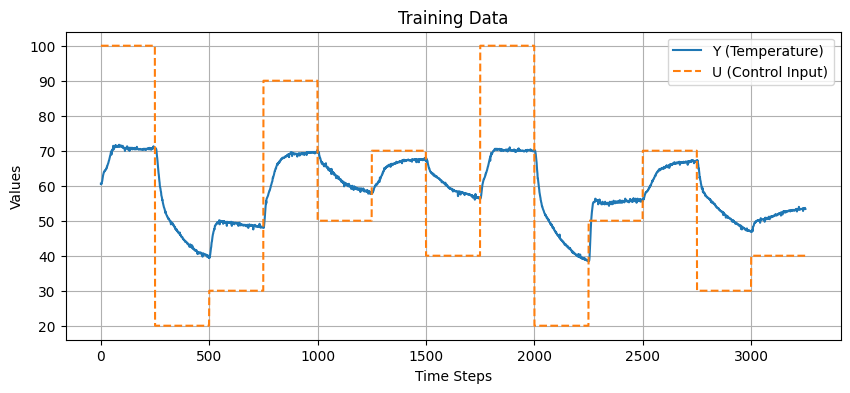

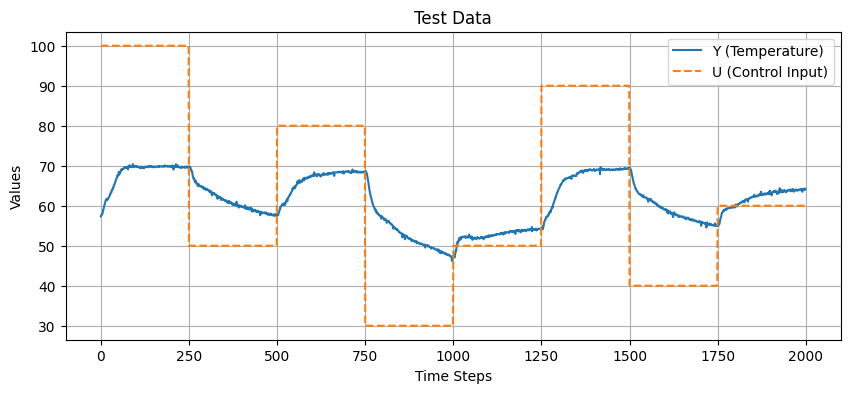


--- TRAIN STEP INFO ---
Step at t = 250: u changed from 100.0 to 20.0 (Δu = 176.0)
Step at t = 500: u changed from 20.0 to 30.0 (Δu = 10.0)
Step at t = 750: u changed from 30.0 to 90.0 (Δu = 60.0)
Step at t = 1000: u changed from 90.0 to 50.0 (Δu = 216.0)
Step at t = 1250: u changed from 50.0 to 70.0 (Δu = 20.0)
Step at t = 1500: u changed from 70.0 to 40.0 (Δu = 226.0)
Step at t = 1750: u changed from 40.0 to 100.0 (Δu = 60.0)
Step at t = 2000: u changed from 100.0 to 20.0 (Δu = 176.0)
Step at t = 2250: u changed from 20.0 to 50.0 (Δu = 30.0)
Step at t = 2500: u changed from 50.0 to 70.0 (Δu = 20.0)
Step at t = 2750: u changed from 70.0 to 30.0 (Δu = 216.0)
Step at t = 3000: u changed from 30.0 to 40.0 (Δu = 10.0)


C:\Users\ivadu\AppData\Local\Temp\ipykernel_36400\3661449647.py:74: RuntimeWarning: overflow encountered in scalar subtract
  delta = u_raw[idx + delay] - dif


ValueError: too many values to unpack (expected 3)

In [ ]:
# Remake of the code without scaling the data

from scipy.io import loadmat
import os
import matplotlib.pyplot as plt
import numpy as np
import pickle

# Load training and testing data from .mat files
train_data = loadmat('train_data_ident.mat')
test_data = loadmat('test_data_ident.mat')

# Extract control input (U) and output (Y) signals
u_train = train_data['Utrain'][:, 0]
x_train = train_data['Ytrain'][:, 0]
u_test = test_data['Utest'][:, 0]
x_test = test_data['Ytest'][:, 0]

# Save raw (unscaled) data
train_real = {'Y': x_train.reshape(-1, 1), 'U': u_train.reshape(-1, 1)}
test_real = {'Y': x_test.reshape(-1, 1), 'U': u_test.reshape(-1, 1)}

with open('train_real.pkl', 'wb') as file:
    pickle.dump(train_real, file)

with open('test_real.pkl', 'wb') as file:
    pickle.dump(test_real, file)

# Step detection
step_changes = np.where(np.diff(u_test) != 0)[0] + 1
step_starts = np.insert(step_changes, 0, 0)
step_values = u_test[step_starts]

# Visualize raw signals
plt.figure(figsize=(10, 4))
plt.plot(x_train, label='Y (Temperature)')
plt.plot(u_train, label='U (Control Input)', linestyle='dashed')
plt.xlabel('Time Steps')
plt.ylabel('Values')
plt.legend()
plt.title("Training Data")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(x_test, label='Y (Temperature)')
plt.plot(u_test, label='U (Control Input)', linestyle='dashed')
plt.xlabel('Time Steps')
plt.ylabel('Values')
plt.legend()
plt.title("Test Data")
plt.grid(True)
plt.show()


# Function to extract normalized step responses without scaling
def extract_steps(u_raw, x_raw, step_size=250, delay=100, threshold=0.01, initial_ref=None, label=""):
    delta_u = np.diff(u_raw, prepend=u_raw[0])
    step_starts = np.where(np.abs(delta_u) > threshold)[0]
    if len(step_starts) == 0:
        return np.array([]), [], []
    if step_starts[0] == 0:
        step_starts = step_starts[1:]

    ident_data = []
    step_info = []
    dif = initial_ref if initial_ref is not None else u_raw[0]

    print(f"\n--- {label.upper()} STEP INFO ---")
    for idx in step_starts:
        if idx + step_size > len(u_raw):
            continue

        delta = u_raw[idx + delay] - dif
        if delta == 0:
            continue

        normx = (x_raw[idx:idx + step_size] - x_raw[idx]) / delta
        ident_data.append(normx.flatten())

        print(f"Step at t = {idx}: u changed from {dif:.1f} to {u_raw[idx + delay]:.1f} (Δu = {delta:.1f})")

        step_info.append({
            "index": idx,
            "u_before": dif,
            "u_after": u_raw[idx + delay],
            "delta_u": delta
        })

        dif = u_raw[idx + delay]

    return np.array(ident_data), step_starts, step_info,

# Extract step response data (without scaling)
train_steps, train_indices, train_info = extract_steps(u_train, x_train, step_size=250, label="train", initial_ref=u_train[0])
test_steps, test_indices, test_info = extract_steps(u_test, x_test, step_size=250, label="test", initial_ref=u_test[0])

# Combine and plot
all_ident_data = np.vstack((train_steps, test_steps))

plt.figure(figsize=(12, 5))
for row in all_ident_data:
    plt.plot(row)
plt.title('Normalized Step Responses (Train + Test) - Unscaled')
plt.xlabel('Time [samples]')
plt.ylabel('Normalized Output')
plt.grid(True)
plt.show()

# Time constant estimation
mean_row = np.mean(all_ident_data, axis=0)
K = np.mean(mean_row[-10:])
target_value = 0.632 * K
time_constant_idx = np.where(mean_row >= target_value)[0][0]

print(f"Steady-state gain K ≈ {K:.4f}")
print(f"Time constant (τ) ≈ {time_constant_idx} samples")

plt.figure(figsize=(10, 6))
plt.plot(mean_row)
plt.axhline(K, linestyle='--', color='gray', label='Steady State K')
plt.axhline(target_value, linestyle='--', color='orange', label='63.2% of K')
plt.axvline(time_constant_idx, linestyle='--', color='red', label='τ')
plt.xlabel('Index')
plt.ylabel('Value')
plt.title('Mean Step Response')
plt.legend()
plt.grid(True)
plt.show()


NameError: name 'dif' is not defined